# Implement histogram equalization on the grayscale image

    * Display both the original grayscale image and the histogram-equalized image side by side for comparison.
    * Display both the histogram of original grayscale image and the histogram of equalized image side by side for comparison.

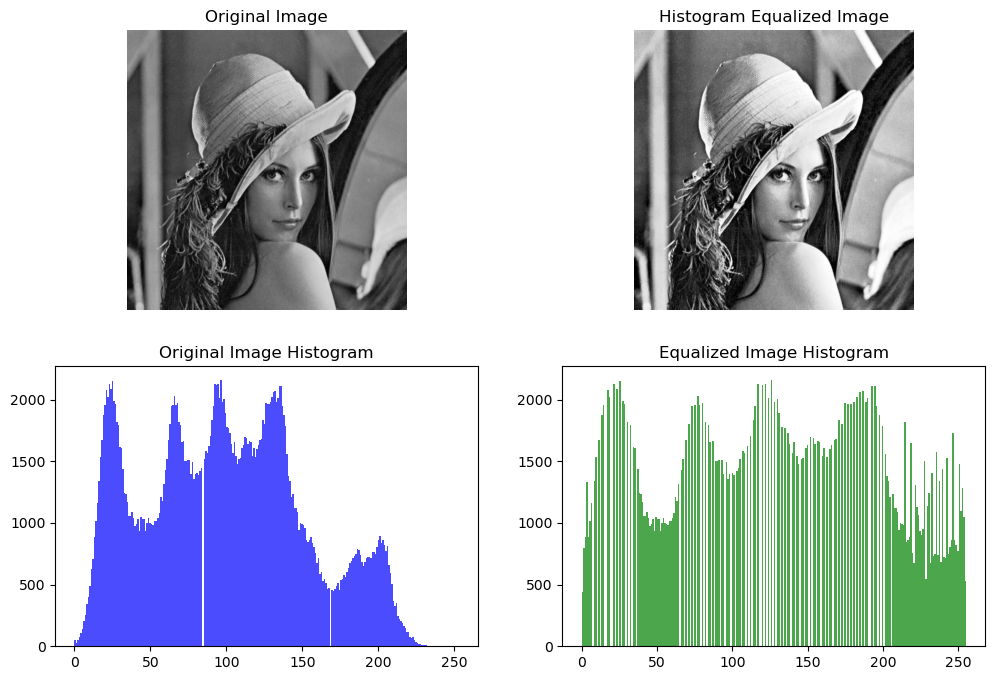

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def read_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Error: Unable to read image at {image_path}")
    return img
'''
def histogram_equalization(image):
    return cv2.equalizeHist(image)
'''
def histogram_equalization(image):
    hist = np.zeros(256, dtype=int)
    for pixel in image.ravel():
        hist[pixel] += 1

    num_pixels = image.size
    pdf = hist / num_pixels

    cdf = np.cumsum(pdf)

    cdf_normalized = np.round(cdf * 255).astype(np.uint8)

    equalized_image = cdf_normalized[image]

    return equalized_image
    
def plot_histograms(original, equalized):
    plt.figure(figsize=(12, 8))
    plt.subplot(2, 2, 1)
    plt.imshow(original, cmap='gray')
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(2, 2, 2)
    plt.imshow(equalized, cmap='gray')
    plt.title("Histogram Equalized Image")
    plt.axis("off")

    plt.subplot(2, 2, 3)
    plt.hist(original.ravel(), bins=256, color='blue', alpha=0.7)
    plt.title("Original Image Histogram")

    plt.subplot(2, 2, 4)
    plt.hist(equalized.ravel(), bins=256, color='green', alpha=0.7)
    plt.title("Equalized Image Histogram")

    plt.savefig(f"outimg_problem4.png")
    plt.show()

def main():
    image_path = "../test_imgs/lena.jpg"
    image = read_image(image_path)
    equalized_image = histogram_equalization(image)

    plot_histograms(image, equalized_image)

if __name__ == "__main__":
    main()
